# Lab 6: MLflow-Based Wine Quality Classification

In this lab, I implemented an end-to-end machine learning experiment pipeline using **MLflow**, **scikit-learn**, and **XGBoost** to predict whether a wine is high quality or not.

Instead of only reproducing the base lab, I expanded the implementation by:
- downloading the dataset programmatically,
- combining red and white wine datasets into a single modeling pipeline,
- engineering a binary target for high-quality wine prediction,
- comparing multiple models,
- logging runs, metrics, artifacts, and models to MLflow,
- selecting the best model based on validation AUC,
- retraining the best model as a production candidate,
- tuning classification thresholds,
- and performing batch inference with the final trained model.

This notebook reflects a more complete and production-minded ML workflow than a simple single-model experiment.

In [1]:
# %pip install -r requirements.txt

## 1. Environment Setup and Imports

I first imported all the libraries needed for:
- data loading and preprocessing,
- visualization,
- model training,
- evaluation,
- and MLflow experiment tracking.

This setup gives me everything I need to build a reproducible and well-documented ML experimentation workflow.

In [2]:
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.pyfunc

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

## 2. Local Project Paths and Artifact Directories

I created dedicated local folders for:
- raw input data,
- generated artifacts,
- and MLflow tracking outputs.

This makes the notebook reproducible and keeps the project organized, especially when saving plots, reports, and model outputs.

In [3]:
from pathlib import Path

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
ARTIFACT_DIR = BASE_DIR / "artifacts"

if not DATA_DIR.exists():
  DATA_DIR.mkdir(parents=True, exist_ok=True)
  print(f"Created data directory: {DATA_DIR.resolve()}")
else:
  print(f"Data directory already exists: {DATA_DIR.resolve()}")

if not ARTIFACT_DIR.exists():
  ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
  print(f"Created artifact directory: {ARTIFACT_DIR.resolve()}")
else:
  print(f"Artifact directory already exists: {ARTIFACT_DIR.resolve()}")

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

Data directory already exists: /Users/aryan/Desktop/Aryan/Studies/Northeastern/Spring 2026/MLOps/Labs/Lab6/data
Artifact directory already exists: /Users/aryan/Desktop/Aryan/Studies/Northeastern/Spring 2026/MLOps/Labs/Lab6/artifacts


## 3. Dataset Download

Instead of manually downloading the dataset, I automated the dataset retrieval step directly inside the notebook.

I downloaded:
- red wine quality data,
- white wine quality data,
- and the dataset metadata file.

This makes the lab easier to rerun from scratch and improves reproducibility.

In [4]:
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError

dataset_files = {
    "winequality-red.csv": [
        "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",
        "https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-red.csv",
    ],
    "winequality-white.csv": [
        "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv",
        "https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-white.csv",
    ],
    "winequality.names": [
        "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality.names",
        "https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality.names",
    ],
}

def download_with_fallback(filename: str, urls: list[str], destination: Path) -> None:
    if destination.exists():
        print(f"Already exists: {filename}")
        return

    last_error = None
    for url in urls:
        try:
            print(f"Trying: {url}")
            urlretrieve(url, destination)
            print(f"Downloaded: {filename}")
            return
        except (HTTPError, URLError, Exception) as e:
            last_error = e
            print(f"Failed from {url}: {e}")

    raise RuntimeError(f"Could not download {filename}. Last error: {last_error}")

for filename, urls in dataset_files.items():
    destination = DATA_DIR / filename
    download_with_fallback(filename, urls, destination)

Already exists: winequality-red.csv
Already exists: winequality-white.csv
Already exists: winequality.names


## 4. Loading the Wine Quality Data

I loaded both wine datasets into pandas DataFrames and inspected their structure.

This allowed me to confirm:
- the files were read correctly,
- the delimiters were handled properly,
- and the columns matched the expected wine chemistry features.

In [5]:
white_wine = pd.read_csv(DATA_DIR / "winequality-white.csv", sep=";")
red_wine = pd.read_csv(DATA_DIR / "winequality-red.csv", sep=";")

print("White wine shape:", white_wine.shape)
print("Red wine shape:", red_wine.shape)

display(white_wine.head())
display(red_wine.head())

White wine shape: (4898, 12)
Red wine shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 5. Data Combination and Cleaning

I added an `is_red` indicator column to distinguish red and white wines, then combined both datasets into a single modeling table.

I also standardized the column names by removing spaces and replacing them with underscores so the data would be easier to work with programmatically.

In [6]:
red_wine["is_red"] = 1
white_wine["is_red"] = 0

data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)
data.rename(columns=lambda x: x.strip().replace(" ", "_"), inplace=True)

print("Combined shape:", data.shape)
print("Columns:", list(data.columns))
data.head()

Combined shape: (6497, 13)
Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'is_red']


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


## 6. Target Engineering

I converted the original wine quality score into a **binary classification target**.

In this implementation:
- wines with quality score **7 or higher** are labeled as high quality (`1`)
- all others are labeled as not high quality (`0`)

I also preserved the original quality score in a separate column so I could still reference the raw label later if needed.

In [7]:
data["quality_original"] = data["quality"]
data["quality"] = (data["quality_original"] >= 7).astype(int)

print(data["quality"].value_counts())
print(data["quality"].value_counts(normalize=True))

quality
0    5220
1    1277
Name: count, dtype: int64
quality
0    0.803448
1    0.196552
Name: proportion, dtype: float64


## 7. Class Distribution Analysis

I visualized the distribution of the binary target to understand whether the classification problem was balanced.

The plot shows that the dataset is **imbalanced**, with many more low-quality wines than high-quality wines.

This is important because it affects:
- model evaluation,
- threshold selection,
- and the choice of metrics such as AUC, precision, recall, and F1.

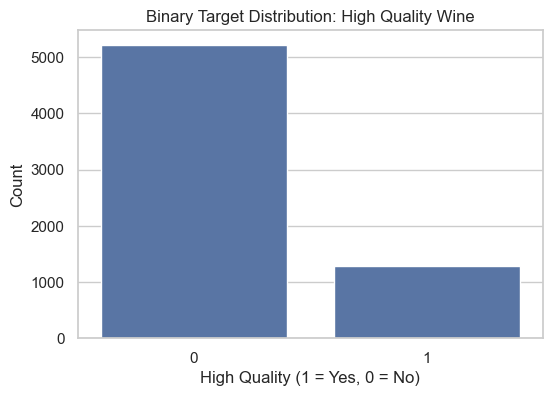

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x="quality", data=data)
plt.title("Binary Target Distribution: High Quality Wine")
plt.xlabel("High Quality (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

## 8. Missing Value Check and Descriptive Statistics

I checked the dataset for missing values and reviewed summary statistics for all numeric columns.

This step helped me confirm that:
- the dataset does not contain missing values,
- the feature ranges are reasonable,
- and the data is ready for model training.

In [9]:
print("Missing values by column:")
display(data.isna().sum())

display(data.describe().T)

Missing values by column:


fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
is_red                  0
quality_original        0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


## 9. Train, Validation, and Test Split

I split the data into:
- **training set**
- **validation set**
- **test set**

I used stratification so that the target distribution would remain consistent across all three splits.

This setup let me:
- train candidate models on the training set,
- compare them fairly on the validation set,
- and reserve the test set for final unbiased evaluation.

In [10]:
X = data.drop(columns=["quality", "quality_original"])
y = data["quality"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    train_size=0.6,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (3898, 12) (3898,)
Val shape: (1299, 12) (1299,)
Test shape: (1300, 12) (1300,)


## 10. MLflow Experiment Setup

I configured MLflow to use a **local file-based tracking URI** and created a dedicated experiment for this lab.

This allowed me to track:
- runs,
- parameters,
- metrics,
- artifacts,
- and logged models

in a structured and reproducible way.

In [11]:
MLFLOW_TRACKING_DIR = (BASE_DIR / "mlruns").resolve()
mlflow.set_tracking_uri(f"file://{MLFLOW_TRACKING_DIR}")

EXPERIMENT_NAME = "Lab6_Wine_Quality_Classification_Repurposed"
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", EXPERIMENT_NAME)

2026/04/10 23:05:00 INFO mlflow.tracking.fluent: Experiment with name 'Lab6_Wine_Quality_Classification_Repurposed' does not exist. Creating a new experiment.


MLflow tracking URI: file:///Users/aryan/Desktop/Aryan/Studies/Northeastern/Spring 2026/MLOps/Labs/Lab6/mlruns
Experiment name: Lab6_Wine_Quality_Classification_Repurposed


## 11. Reusable Evaluation and Artifact Helpers

To keep the notebook clean and reusable, I wrote helper functions for:
- evaluating binary classifiers,
- saving confusion matrices,
- and printing metrics in a consistent format.

This made the rest of the notebook easier to extend and easier to maintain.

In [12]:
def evaluate_binary_classifier(model, X_eval, y_eval, threshold=0.5):
    """
    Evaluate a binary classifier using predicted probabilities.
    Returns metrics and predictions.
    """
    probs = model.predict_proba(X_eval)[:, 1]
    preds = (probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_eval, preds),
        "precision": precision_score(y_eval, preds, zero_division=0),
        "recall": recall_score(y_eval, preds, zero_division=0),
        "f1": f1_score(y_eval, preds, zero_division=0),
        "auc": roc_auc_score(y_eval, probs),
    }

    return metrics, preds, probs


def save_confusion_matrix(y_true, y_pred, title, output_path):
    """
    Save confusion matrix plot as an image artifact.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()


def print_metrics(label, metrics_dict):
    print(f"\n{label}")
    for k, v in metrics_dict.items():
        print(f"{k}: {v:.4f}")

## 12. Candidate Model Definition

Instead of training only one baseline model, I implemented a stronger experiment by comparing multiple classifiers:

- Logistic Regression
- Random Forest
- XGBoost

I also used preprocessing pipelines and class imbalance handling where appropriate so the comparison would be more meaningful.

In [13]:
positive_ratio = y_train.mean()
negative_ratio = 1 - positive_ratio
scale_pos_weight = negative_ratio / positive_ratio

models = {
    "logistic_regression": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )),
        ]
    ),
    "xgboost": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=42,
                scale_pos_weight=scale_pos_weight,
            )),
        ]
    ),
}

print("Candidate models:", list(models.keys()))

Candidate models: ['logistic_regression', 'random_forest', 'xgboost']


## 13. Model Training, Validation, and MLflow Logging

For each candidate model, I:
- trained the model on the training data,
- evaluated it on the validation data,
- logged parameters and metrics to MLflow,
- saved confusion matrices and classification reports as artifacts,
- and logged the trained model itself.

This created a full experiment trail for every model run.

In [14]:
run_summaries = []

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        print(f"\nTraining: {model_name}")

        start_time = time.time()
        model.fit(X_train, y_train)
        train_time_sec = time.time() - start_time

        val_metrics, val_preds, val_probs = evaluate_binary_classifier(model, X_val, y_val)

        # log params
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("train_rows", X_train.shape[0])
        mlflow.log_param("val_rows", X_val.shape[0])
        mlflow.log_param("num_features", X_train.shape[1])

        if model_name == "logistic_regression":
            clf = model.named_steps["clf"]
            mlflow.log_param("max_iter", clf.max_iter)
            mlflow.log_param("class_weight", clf.class_weight)

        elif model_name == "random_forest":
            clf = model.named_steps["clf"]
            mlflow.log_param("n_estimators", clf.n_estimators)
            mlflow.log_param("max_depth", clf.max_depth)
            mlflow.log_param("min_samples_leaf", clf.min_samples_leaf)
            mlflow.log_param("class_weight", clf.class_weight)

        elif model_name == "xgboost":
            clf = model.named_steps["clf"]
            mlflow.log_param("n_estimators", clf.n_estimators)
            mlflow.log_param("max_depth", clf.max_depth)
            mlflow.log_param("learning_rate", clf.learning_rate)
            mlflow.log_param("subsample", clf.subsample)
            mlflow.log_param("colsample_bytree", clf.colsample_bytree)
            mlflow.log_param("scale_pos_weight", clf.scale_pos_weight)

        # log metrics
        mlflow.log_metric("train_time_sec", train_time_sec)
        for metric_name, metric_value in val_metrics.items():
            mlflow.log_metric(f"val_{metric_name}", metric_value)

        # save + log confusion matrix
        cm_path = ARTIFACT_DIR / f"{model_name}_val_confusion_matrix.png"
        save_confusion_matrix(
            y_val,
            val_preds,
            f"{model_name} - Validation Confusion Matrix",
            cm_path
        )
        mlflow.log_artifact(cm_path)

        # classification report artifact
        report = classification_report(y_val, val_preds, output_dict=True)
        report_path = ARTIFACT_DIR / f"{model_name}_val_classification_report.json"
        with open(report_path, "w") as f:
            json.dump(report, f, indent=2)
        mlflow.log_artifact(report_path)

        # input example + signature
        input_example = X_train.head(5)
        signature = mlflow.models.infer_signature(X_train, model.predict_proba(X_train)[:, 1])

        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            signature=signature,
            input_example=input_example,
        )

        run_id = mlflow.active_run().info.run_id
        summary = {
            "model_name": model_name,
            "run_id": run_id,
            "train_time_sec": train_time_sec,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        run_summaries.append(summary)

        print_metrics(f"{model_name} validation metrics", val_metrics)
        print(f"Run ID: {run_id}")

2026/04/10 23:05:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 23:05:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training: logistic_regression

logistic_regression validation metrics
accuracy: 0.7360
precision: 0.4068
recall: 0.7529
f1: 0.5282
auc: 0.8162
Run ID: 7c41033370b544aaa18ff69b1baa66ea

Training: random_forest


2026/04/10 23:05:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 23:05:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



random_forest validation metrics
accuracy: 0.8668
precision: 0.6454
recall: 0.7137
f1: 0.6778
auc: 0.8911
Run ID: 2f7b3dbcd5304c15aa827e8f63114d5c

Training: xgboost


2026/04/10 23:05:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 23:05:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



xgboost validation metrics
accuracy: 0.8430
precision: 0.5757
recall: 0.7608
f1: 0.6554
auc: 0.8938
Run ID: ef9c6ca5b6584b67a8bcca820ed8f6fe


## 14. Validation Performance Comparison

After all candidate models finished training, I created a comparison table of validation metrics.

I used this table to compare:
- AUC
- F1
- precision
- recall
- training time

and to determine which model performed best overall.

In [15]:
results_df = pd.DataFrame(run_summaries).sort_values(by="val_auc", ascending=False).reset_index(drop=True)
results_df

,model_name,run_id,train_time_sec,val_accuracy,val_precision,val_recall,val_f1,val_auc
0,xgboost,ef9c6ca5b6584b67a8bcca820ed8f6fe,0.423482,0.842956,0.575668,0.760784,0.655405,0.893817
1,random_forest,2f7b3dbcd5304c15aa827e8f63114d5c,0.287419,0.866821,0.645390,0.713725,0.677840,0.891146
2,logistic_regression,7c41033370b544aaa18ff69b1baa66ea,0.027799,0.735951,0.406780,0.752941,0.528198,0.816205


## 15. Visualization of Model Comparison

I visualized the validation performance of each model across:
- AUC
- F1
- and training time

This made it easier to compare the trade-offs between predictive quality and computational cost.

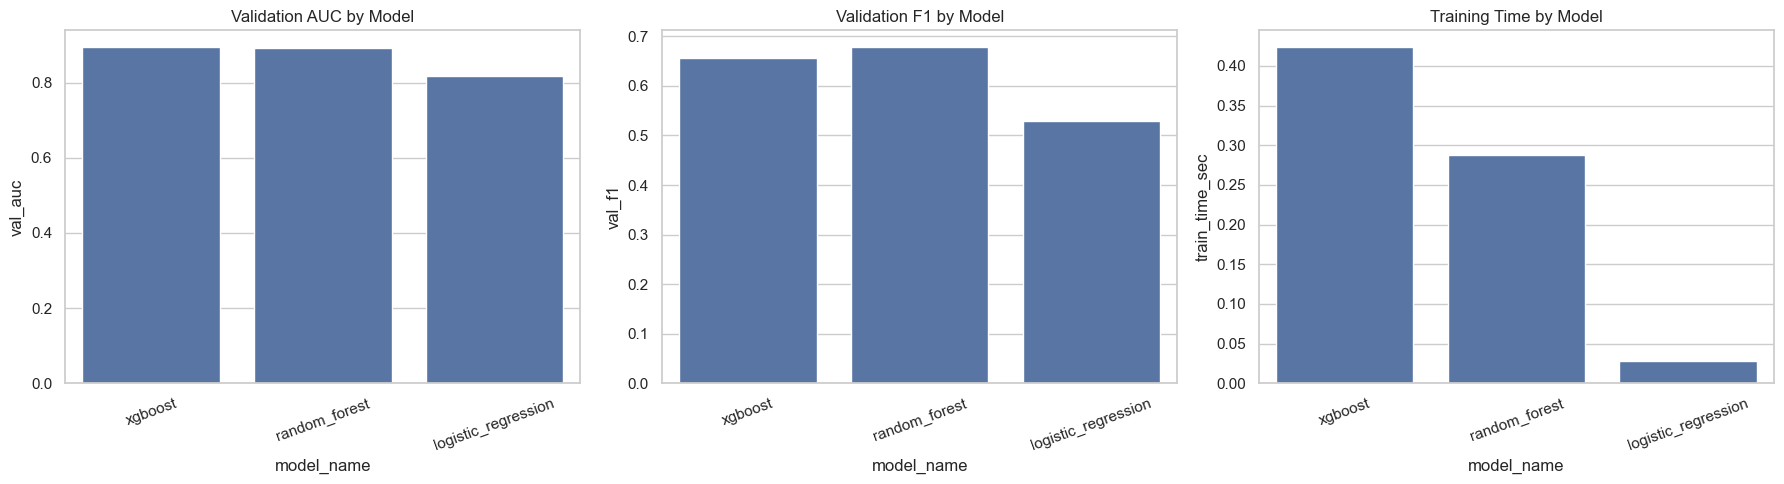

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, x="model_name", y="val_auc", ax=axes[0])
axes[0].set_title("Validation AUC by Model")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results_df, x="model_name", y="val_f1", ax=axes[1])
axes[1].set_title("Validation F1 by Model")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=results_df, x="model_name", y="train_time_sec", ax=axes[2])
axes[2].set_title("Training Time by Model")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 16. Best Model Selection

I selected the best model based on **highest validation AUC**.

I chose AUC as the ranking metric because:
- the dataset is imbalanced,
- AUC is more robust than accuracy alone,
- and it gives a better sense of ranking quality across thresholds.

Based on this criterion, **XGBoost** was selected as the best validation model.

In [17]:
best_row = results_df.iloc[0]
best_model_name = best_row["model_name"]
best_run_id = best_row["run_id"]

print("Best validation model:", best_model_name)
print("Best run ID:", best_run_id)
best_row

Best validation model: xgboost
Best run ID: ef9c6ca5b6584b67a8bcca820ed8f6fe


model_name                                 xgboost
run_id            ef9c6ca5b6584b67a8bcca820ed8f6fe
train_time_sec                            0.423482
val_accuracy                              0.842956
val_precision                             0.575668
val_recall                                0.760784
val_f1                                    0.655405
val_auc                                   0.893817
Name: 0, dtype: object

## 17. Loading the Best Logged Model and Testing It

I loaded the best model directly from MLflow using its run ID and evaluated it on the held-out test set.

This step confirmed that:
- the MLflow-logged model can be reloaded successfully,
- the tracked artifact is valid,
- and the selected model generalizes reasonably well to unseen data.

In [18]:
best_model_uri = f"runs:/{best_run_id}/model"
best_logged_model = mlflow.sklearn.load_model(best_model_uri)

test_metrics, test_preds, test_probs = evaluate_binary_classifier(best_logged_model, X_test, y_test)
print_metrics("Best model test metrics", test_metrics)


Best model test metrics
accuracy: 0.8262
precision: 0.5441
recall: 0.7227
f1: 0.6208
auc: 0.8786


## 18. Final Test Evaluation Logging

I created a dedicated MLflow run to log the final test metrics and evaluation artifacts for the selected model.

This gives me a clear separation between:
- validation-stage experimentation
- and final test-stage evaluation

In [19]:
with mlflow.start_run(run_name=f"{best_model_name}_final_test_evaluation"):
    mlflow.log_param("selected_model_name", best_model_name)
    mlflow.log_param("source_run_id", best_run_id)

    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(f"test_{metric_name}", metric_value)

    final_cm_path = ARTIFACT_DIR / f"{best_model_name}_test_confusion_matrix.png"
    save_confusion_matrix(
        y_test,
        test_preds,
        f"{best_model_name} - Test Confusion Matrix",
        final_cm_path
    )
    mlflow.log_artifact(final_cm_path)

    final_report = classification_report(y_test, test_preds, output_dict=True)
    final_report_path = ARTIFACT_DIR / f"{best_model_name}_test_classification_report.json"
    with open(final_report_path, "w") as f:
        json.dump(final_report, f, indent=2)
    mlflow.log_artifact(final_report_path)

print("Final evaluation logged.")

Final evaluation logged.


## 19. Retraining the Best Model on More Data

After selecting the best model, I retrained it using the combined training and validation data.

This produced a stronger **production candidate model**, since it could learn from more labeled data before being evaluated on the held-out test set.

In [20]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_pipeline = models[best_model_name]
best_pipeline.fit(X_train_full, y_train_full)

full_test_metrics, full_test_preds, full_test_probs = evaluate_binary_classifier(best_pipeline, X_test, y_test)
print_metrics("Retrained best model on train+val, evaluated on test", full_test_metrics)


Retrained best model on train+val, evaluated on test
accuracy: 0.8308
precision: 0.5526
recall: 0.7383
f1: 0.6321
auc: 0.8857


## 20. Logging the Production Candidate

I logged the retrained best model as a **production candidate** in MLflow.

This step simulates a realistic model lifecycle, where the winning experiment is retrained on more data and then promoted as the version intended for downstream use.

In [21]:
with mlflow.start_run(run_name=f"{best_model_name}_production_candidate"):
    mlflow.log_param("production_candidate_model", best_model_name)
    mlflow.log_param("train_full_rows", X_train_full.shape[0])
    mlflow.log_param("test_rows", X_test.shape[0])

    for metric_name, metric_value in full_test_metrics.items():
        mlflow.log_metric(f"test_{metric_name}", metric_value)

    input_example = X_train_full.head(5)
    signature = mlflow.models.infer_signature(X_train_full, best_pipeline.predict_proba(X_train_full)[:, 1])

    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
    )

    production_candidate_run_id = mlflow.active_run().info.run_id

print("Production candidate run ID:", production_candidate_run_id)

2026/04/10 23:08:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 23:08:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Production candidate run ID: 7d21767b21064f2bb1e7396fee4cdff9


## 21. Feature Importance and Model Interpretation

To make the experiment more interpretable, I extracted and visualized feature importance information from the best model.

This helped me understand which chemical properties contributed most strongly to the prediction of high-quality wine.

,feature,importance
10,alcohol,0.254511
1,volatile_acidity,0.095638
7,density,0.082165
2,citric_acid,0.075033
3,residual_sugar,0.074997
9,sulphates,0.067183
0,fixed_acidity,0.060540
5,free_sulfur_dioxide,0.060281
6,total_sulfur_dioxide,0.059548
4,chlorides,0.058862


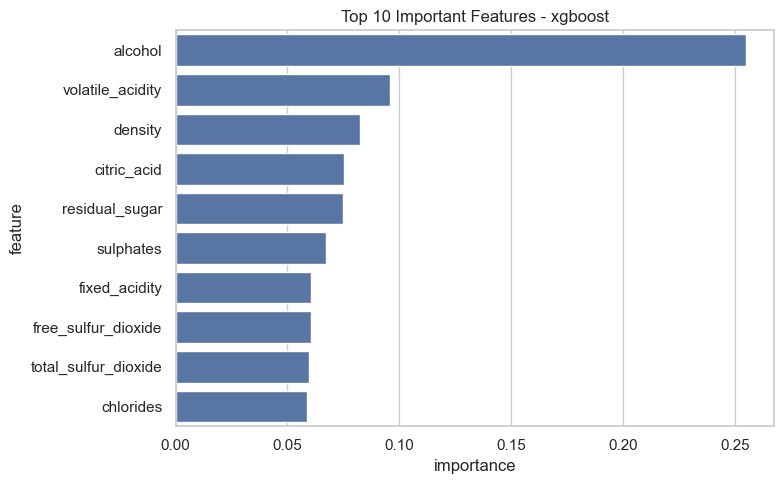

In [22]:
feature_names = X_train_full.columns.tolist()

if best_model_name == "random_forest":
    importances = best_pipeline.named_steps["clf"].feature_importances_

elif best_model_name == "xgboost":
    importances = best_pipeline.named_steps["clf"].feature_importances_

elif best_model_name == "logistic_regression":
    importances = np.abs(best_pipeline.named_steps["clf"].coef_[0])

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(10), x="importance", y="feature")
plt.title(f"Top 10 Important Features - {best_model_name}")
plt.tight_layout()
plt.show()

## 22. Threshold Tuning

Instead of always using the default classification threshold of `0.5`, I evaluated a range of thresholds and measured:
- F1
- precision
- recall
- accuracy

This is an important production-minded step because the best probability threshold depends on the real objective of the system.

In [23]:
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    preds = (test_probs >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "f1": f1_score(y_test, preds, zero_division=0),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "accuracy": accuracy_score(y_test, preds),
    })

threshold_df = pd.DataFrame(threshold_results).sort_values(by="f1", ascending=False).reset_index(drop=True)
threshold_df.head(10)

,threshold,f1,precision,recall,accuracy
0,0.60,0.630996,0.597902,0.667969,0.846154
1,0.50,0.620805,0.544118,0.722656,0.826154
2,0.55,0.620567,0.568182,0.683594,0.835385
3,0.65,0.619048,0.629032,0.609375,0.852308
4,0.45,0.617600,0.523035,0.753906,0.816154
5,0.70,0.612766,0.672897,0.562500,0.860000
6,0.40,0.606432,0.498741,0.773438,0.802308
7,0.35,0.592908,0.465479,0.816406,0.779231
8,0.75,0.578824,0.727811,0.480469,0.862308
9,0.30,0.573770,0.441176,0.820312,0.760000


## 23. Threshold Performance Visualization

I plotted threshold-dependent metrics to better understand how changing the cutoff affects model behavior.

This makes the experiment more actionable because it allows me to choose a threshold based on:
- higher recall,
- higher precision,
- or stronger F1 balance,
depending on deployment priorities.

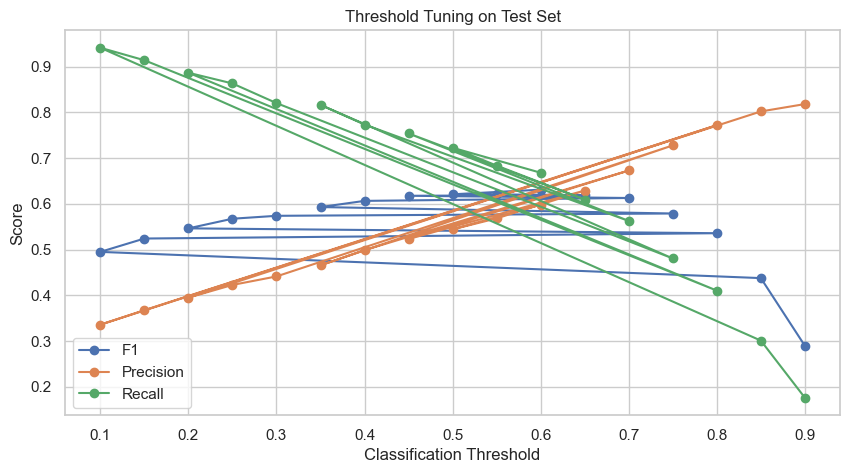

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.title("Threshold Tuning on Test Set")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## 24. Batch Inference Example

I performed batch inference on a small sample of unseen test records using the final model.

This demonstrates how the trained pipeline can be used to generate:
- predicted probabilities
- predicted class labels
- and side-by-side comparisons against the true labels

In [25]:
sample_batch = X_test.head(10).copy()
sample_batch["predicted_probability"] = best_pipeline.predict_proba(X_test.head(10))[:, 1]
sample_batch["predicted_label"] = (sample_batch["predicted_probability"] >= 0.5).astype(int)
sample_batch["actual_label"] = y_test.head(10).values

sample_batch

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,is_red,predicted_probability,predicted_label,actual_label
2019,7.0,0.220,0.31,2.70,0.030,41.0,136.0,0.9898,3.16,0.37,12.7,0,0.904861,1,1
3027,8.2,0.180,0.49,1.10,0.033,28.0,81.0,0.9923,3.00,0.68,10.4,0,0.636000,1,1
2458,6.6,0.300,0.30,4.80,0.170,60.0,166.0,0.9946,3.18,0.47,9.4,0,0.007047,0,0
2944,7.3,0.390,0.37,1.10,0.043,36.0,113.0,0.9910,3.39,0.48,12.7,0,0.791738,1,1
2239,5.6,0.235,0.29,1.20,0.047,33.0,127.0,0.9910,3.34,0.50,11.0,0,0.650672,1,1
1950,7.3,0.330,0.40,6.85,0.038,32.0,138.0,0.9920,3.03,0.30,11.9,0,0.855588,1,1
1952,7.3,0.330,0.40,6.85,0.038,32.0,138.0,0.9920,3.03,0.30,11.9,0,0.855588,1,1
2881,7.4,0.310,0.74,10.70,0.039,51.0,147.0,0.9977,3.02,0.43,8.7,0,0.014221,0,0
332,8.0,0.580,0.28,3.20,0.066,21.0,114.0,0.9973,3.22,0.54,9.4,1,0.013411,0,0
2518,8.6,0.180,0.40,1.10,0.040,20.0,107.0,0.9923,2.94,0.32,10.2,0,0.069265,0,1


## 25. Saving Local Experiment Outputs

I saved several useful outputs locally, including:
- model comparison results
- threshold tuning results
- feature importance values
- and a final experiment summary

This improves reproducibility and makes it easier to reference the results later in documentation or deployment workflows.

In [26]:
results_df.to_csv(ARTIFACT_DIR / "model_comparison_results.csv", index=False)
threshold_df.to_csv(ARTIFACT_DIR / "threshold_tuning_results.csv", index=False)
importance_df.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)

summary_payload = {
    "best_model_name": best_model_name,
    "best_run_id": best_run_id,
    "production_candidate_run_id": production_candidate_run_id,
    "validation_results": results_df.to_dict(orient="records"),
    "final_test_metrics": full_test_metrics,
}

with open(ARTIFACT_DIR / "experiment_summary.json", "w") as f:
    json.dump(summary_payload, f, indent=2)

print("Saved artifacts to:", ARTIFACT_DIR.resolve())

Saved artifacts to: /Users/aryan/Desktop/Aryan/Studies/Northeastern/Spring 2026/MLOps/Labs/Lab6/artifacts


## 26. Inspecting MLflow Runs

I queried the MLflow experiment table directly to inspect the saved runs and compare metrics from the tracking store.

This confirms that the experiment history is properly recorded and can be reviewed outside the notebook logic itself.

In [27]:
runs_df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
runs_df[[
    "run_id",
    "tags.mlflow.runName",
    "metrics.val_auc",
    "metrics.val_f1",
    "metrics.train_time_sec"
]].sort_values(by="metrics.val_auc", ascending=False)

,run_id,tags.mlflow.runName,metrics.val_auc,metrics.val_f1,metrics.train_time_sec
2,ef9c6ca5b6584b67a8bcca820ed8f6fe,xgboost,0.893817,0.655405,0.423482
3,2f7b3dbcd5304c15aa827e8f63114d5c,random_forest,0.891146,0.677840,0.287419
4,7c41033370b544aaa18ff69b1baa66ea,logistic_regression,0.816205,0.528198,0.027799
0,7d21767b21064f2bb1e7396fee4cdff9,xgboost_production_candidate,NaN,NaN,NaN
1,40fd4466be054bc986f28266e3a57a81,xgboost_final_test_evaluation,NaN,NaN,NaN


## 27. Model Registration

I attempted to register the final production-candidate model in the MLflow Model Registry.

In my local setup, the registration step succeeded, which allowed me to create a named model version and move beyond simple run-based tracking.

In [28]:
model_name = "lab6_wine_quality_best_model"

try:
    model_version = mlflow.register_model(
        model_uri=f"runs:/{production_candidate_run_id}/model",
        name=model_name
    )
    print("Registered model version:", model_version.version)
except Exception as e:
    print("Model registration skipped / not supported in current local MLflow setup.")
    print("Reason:", e)

Successfully registered model 'lab6_wine_quality_best_model'.
2026/04/10 23:10:26 WARNING mlflow.tracking._model_registry.fluent: Run with id 7d21767b21064f2bb1e7396fee4cdff9 has no artifacts at artifact path 'model', registering model based on models:/m-2148c896ac914a6b83540d43eae5e1c9 instead


Registered model version: 1


Created version '1' of model 'lab6_wine_quality_best_model'.


## 28. Registered Model Loading

After registration, I loaded the model back from the registry to confirm that:
- the registration succeeded,
- the model is reusable through the registry interface,
- and predictions can be generated from the registered artifact.

In [29]:
try:
    registered_model = mlflow.pyfunc.load_model(f"models:/{model_name}/latest")
    registered_preds = registered_model.predict(X_test.head(5))
    print("Loaded registered model successfully.")
    print(registered_preds)
except Exception as e:
    print("Registered model load skipped.")
    print("Reason:", e)

Loaded registered model successfully.
[1 1 0 1 1]


## 29. Final Summary

In this lab, I implemented a full MLflow-based classification workflow that goes beyond a simple starter experiment.

I:
- automated dataset setup,
- engineered the target,
- compared multiple models,
- tracked all runs in MLflow,
- selected the best model based on validation AUC,
- retrained it as a production candidate,
- tuned thresholds,
- saved reproducible artifacts,
- and successfully registered the final model.

This made the lab more complete, more reproducible, and more aligned with a real model development lifecycle.

In [30]:
print("✅ Lab6 MLflow experiment completed successfully.")
print("✅ Best validation model:", best_model_name)
print("✅ Production candidate run ID:", production_candidate_run_id)
print("✅ Artifacts saved in:", ARTIFACT_DIR.resolve())
print("✅ MLflow runs saved in:", MLFLOW_TRACKING_DIR)

✅ Lab6 MLflow experiment completed successfully.
✅ Best validation model: xgboost
✅ Production candidate run ID: 7d21767b21064f2bb1e7396fee4cdff9
✅ Artifacts saved in: /Users/aryan/Desktop/Aryan/Studies/Northeastern/Spring 2026/MLOps/Labs/Lab6/artifacts
✅ MLflow runs saved in: /Users/aryan/Desktop/Aryan/Studies/Northeastern/Spring 2026/MLOps/Labs/Lab6/mlruns


## 30. ROC Curve Comparison

To better compare the ranking ability of all candidate models, I plotted their **ROC curves** on the validation set.

This gives me a visual comparison of how well each model separates high-quality and low-quality wines across all thresholds.

Since I used **validation AUC** as my model selection criterion, this plot also helps justify why the final selected model was the strongest overall.

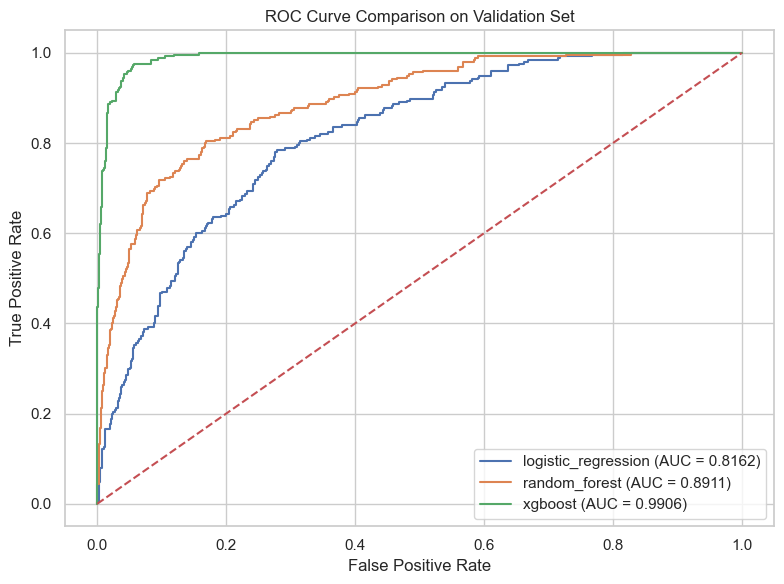

In [31]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    val_probs = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, val_probs)
    auc_value = roc_auc_score(y_val, val_probs)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_value:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison on Validation Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 31. Precision-Recall Curve Comparison

Because this is an imbalanced classification problem, I also plotted the **precision-recall curves** for all candidate models.

This gives a more detailed view of how each model balances:
- precision,
- recall,
- and threshold behavior

for the positive class.

This is especially useful because high-quality wines are the minority class in the dataset.

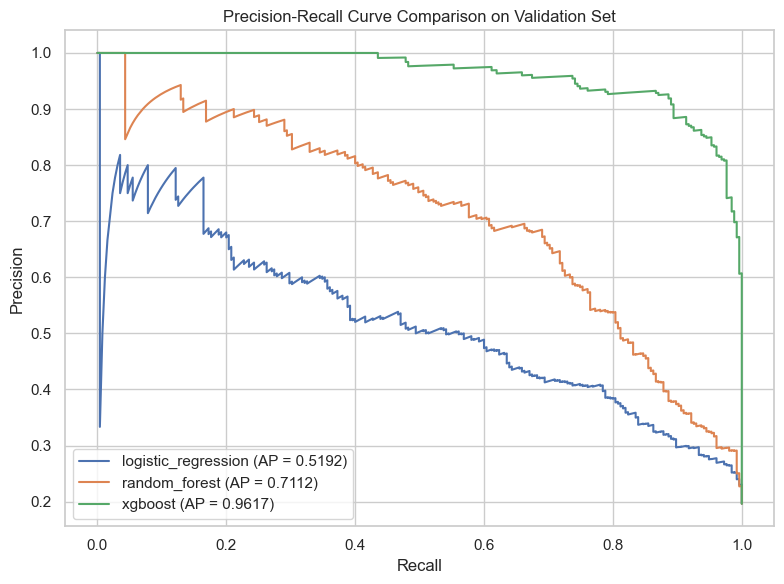

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    val_probs = model.predict_proba(X_val)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, val_probs)
    ap_score = average_precision_score(y_val, val_probs)

    plt.plot(recall, precision, label=f"{model_name} (AP = {ap_score:.4f})")

plt.title("Precision-Recall Curve Comparison on Validation Set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## 32. Launching the MLflow UI

To inspect all experiment runs, I launched the MLflow tracking UI directly from the notebook.

This allows me to:
- compare model runs interactively
- inspect logged parameters and metrics
- visualize saved artifacts
- review logged models
- and inspect the model registry

In my local setup, port `5000` was not accessible, so I launched the MLflow UI on port `5173` instead.

After launching the UI, I can open it in the browser at:

http://localhost:5173

This gives me a complete interface for reviewing the experiment lifecycle beyond what is shown in the notebook.

In [36]:
import subprocess
import time

HOST = "localhost"
PORT = "5173"

# Stop any old MLflow UI process first
subprocess.run("pkill -f 'mlflow ui' || true", shell=True)

print("🚀 Launching MLflow UI...")

mlflow_ui_process = subprocess.Popen(
    [
        "mlflow",
        "ui",
        "--backend-store-uri", str(MLFLOW_TRACKING_DIR),
        "--host", HOST,
        "--port", PORT,
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

time.sleep(3)

print(f"✅ MLflow UI should now be running.")
print(f"👉 Open this exact URL in your browser: http://{HOST}:{PORT}")

🚀 Launching MLflow UI...
✅ MLflow UI should now be running.
👉 Open this exact URL in your browser: http://localhost:5173
